# Heart Dataset

In [2]:
# Importing Important libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from sklearn.metrics import accuracy_score , confusion_matrix , precision_score , f1_score

import warnings
warnings.filterwarnings("ignore")

# Data Collection

#### 1. Import Dataset

In [3]:
df = pd.read_csv('/content/PS_20174392719_1491204439457_log.csv')
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


# Data Understanding

####  2. Finding Head

In [36]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


####  3. Finding Tail

In [37]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


####  4. Finding Type

In [38]:
print(f"Data Type is : {type(df)}")

Data Type is : <class 'pandas.core.frame.DataFrame'>


#### 5. Finding Data Type For Each Columns

In [39]:
df.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


#### 6. Finding Random Sample From Dataset

In [40]:
df.sample()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
5734354,399,CASH_OUT,23575.16,C1305551323,0.0,0.0,C1838646084,2315264.84,2338840.0,0,0


#### 7. Finding Summary of Dataset

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


#### 8. Finding All Column name

In [42]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

#### 9. Finding Out the Shape of Dataset

In [43]:
print(f"There are total rows and columns is : {df.shape}")

There are total rows and columns is : (6362620, 11)


#### 10. Finding out Description of Dataset

In [44]:
df.describe(include="object")

,type,nameOrig,nameDest
count,6362620,6362620,6362620
unique,5,6353307,2722362
top,CASH_OUT,C1530544995,C1286084959
freq,2237500,3,113


In [45]:
df.describe(include="number")

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


#### 11. Finding Null Values

In [46]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


#### 12. Finding Duplicate Values

In [47]:
df.duplicated().sum()

np.int64(0)

#### 13. Checking Target imbalance

In [48]:
# Count each class
class_counts = df['isFraud'].value_counts()
print("Class Distribution:\n", class_counts)

# Check percentage distribution
class_percent = df['isFraud'].value_counts(normalize=True) * 100
print("\nClass Percentage (%):\n", class_percent.round(2))

# Identify majority class percentage
max_percent = class_percent.max()

# Print imbalance status
if max_percent > 80:
    print("\nStatus: Highly Imbalanced Dataset")
elif max_percent > 60:
    print("\nStatus: Moderately Imbalanced Dataset")
else:
    print("\nStatus: Balanced Dataset")

Class Distribution:
 isFraud
0    6354407
1       8213
Name: count, dtype: int64

Class Percentage (%):
 isFraud
0    99.87
1     0.13
Name: proportion, dtype: float64

Status: Highly Imbalanced Dataset


## Data Analysis

#### Data Quality Check

In [49]:
print("\n=== DATA QUALITY ASSESMENT ===")

# Check for missing values
print("\nMissing Values:")
missing_data = df.isnull().sum()
print( missing_data[ missing_data>0 ] )

# Check for duplicates
print(f"\nDuplicate Rows : {df.duplicated().sum()}")


=== DATA QUALITY ASSESMENT ===

Missing Values:
Series([], dtype: int64)

Duplicate Rows : 0


# EDA

### UNIVARIENT ANALYSIS

##### Categorical Variables Analysis


=== CATEGORICAL VARIABLES ===

['type']

--- type ---
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


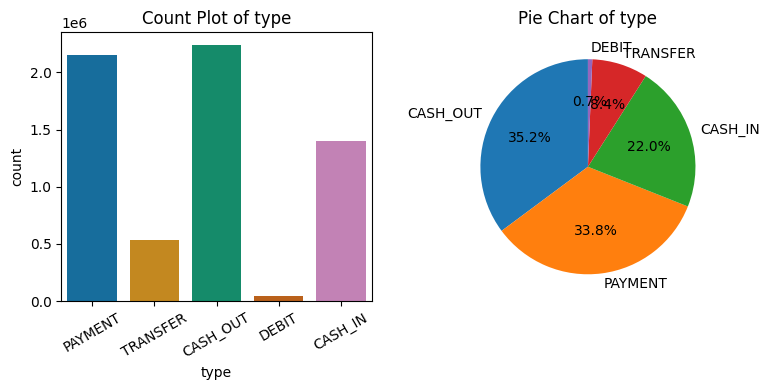

In [50]:
print("\n=== CATEGORICAL VARIABLES ===\n")

categorical_cols = []
for col in df.select_dtypes(include='object').columns:
    if df[col].nunique() < 20:
        categorical_cols.append(col)
print(categorical_cols)

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

    # Visualization
    plt.figure(figsize=(8,4))

    # Count Plot
    plt.subplot(1,2,1)
    sns.countplot(x=df[col], palette="colorblind")
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=30)

    # Pie Chart
    plt.subplot(1,2,2)
    df[col].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=90)
    plt.title(f"Pie Chart of {col}")
    plt.ylabel("")

    plt.tight_layout()
    plt.show()

##### Numerical Variables Analysis


=== Numerical VARIABLES ===

['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

--- step ---

Mean: 243.40
Median: 239.00
Std Dev: 142.33
Min: 1.00
Max: 743.00


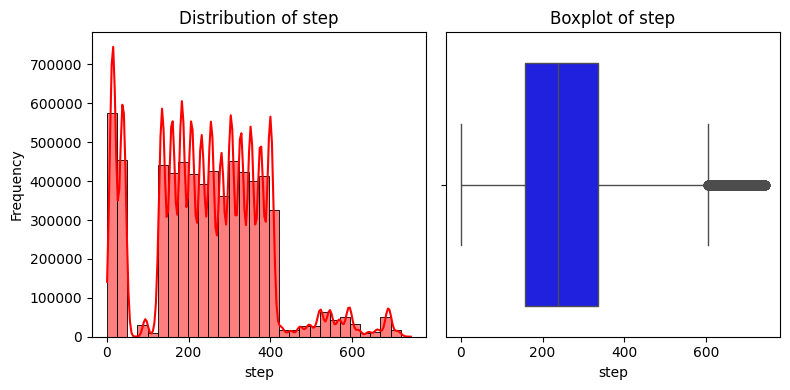


--- amount ---

Mean: 179861.90
Median: 74871.94
Std Dev: 603858.23
Min: 0.00
Max: 92445516.64


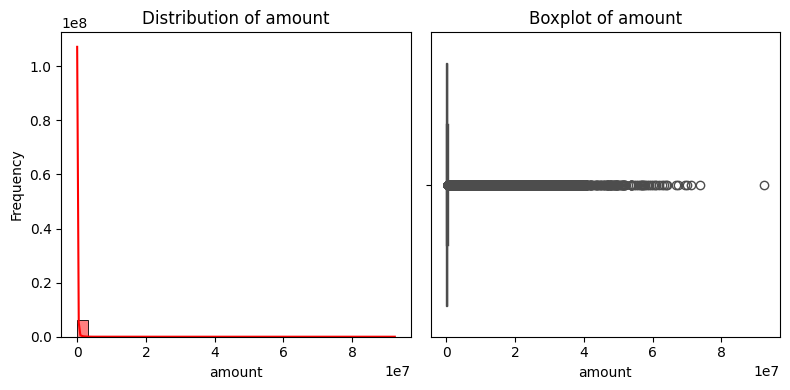


--- oldbalanceOrg ---

Mean: 833883.10
Median: 14208.00
Std Dev: 2888242.67
Min: 0.00
Max: 59585040.37


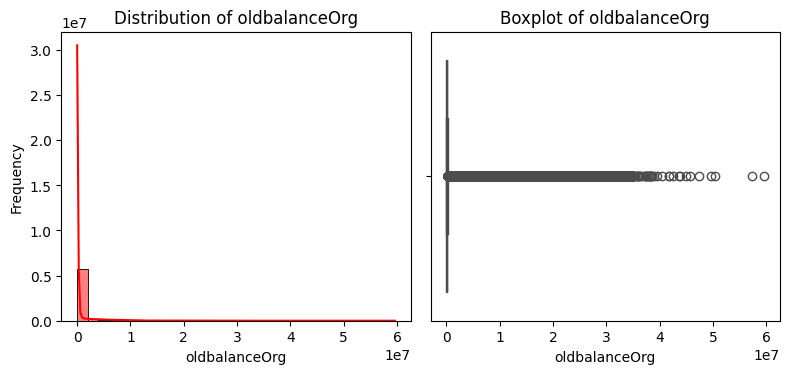


--- newbalanceOrig ---

Mean: 855113.67
Median: 0.00
Std Dev: 2924048.50
Min: 0.00
Max: 49585040.37


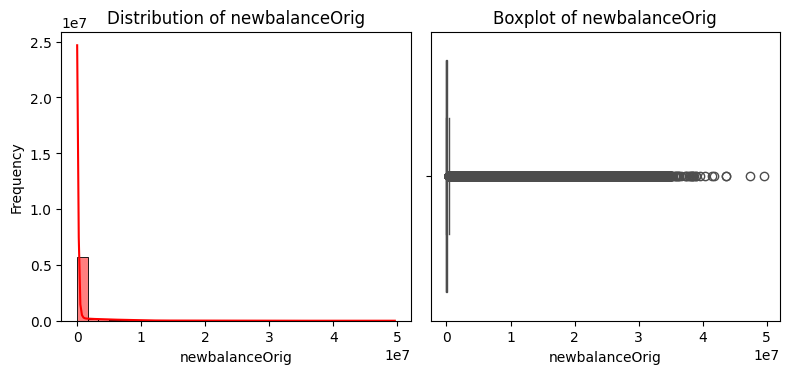


--- oldbalanceDest ---

Mean: 1100701.67
Median: 132705.66
Std Dev: 3399180.11
Min: 0.00
Max: 356015889.35


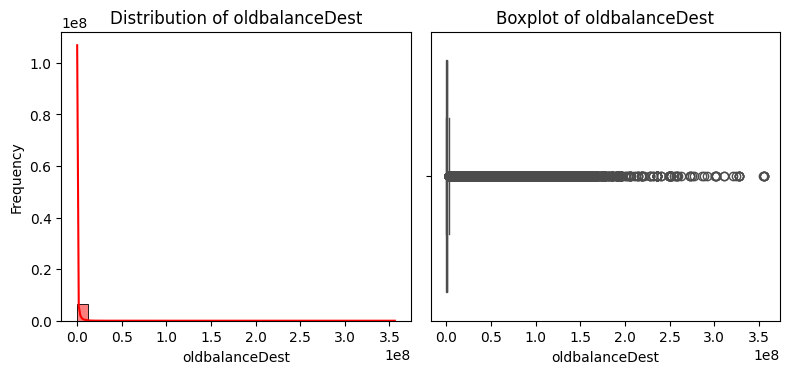


--- newbalanceDest ---

Mean: 1224996.40
Median: 214661.44
Std Dev: 3674128.94
Min: 0.00
Max: 356179278.92


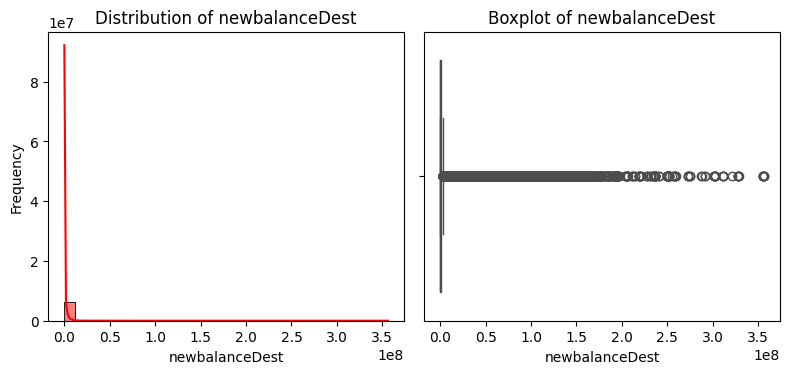


--- isFraud ---

Mean: 0.00
Median: 0.00
Std Dev: 0.04
Min: 0.00
Max: 1.00


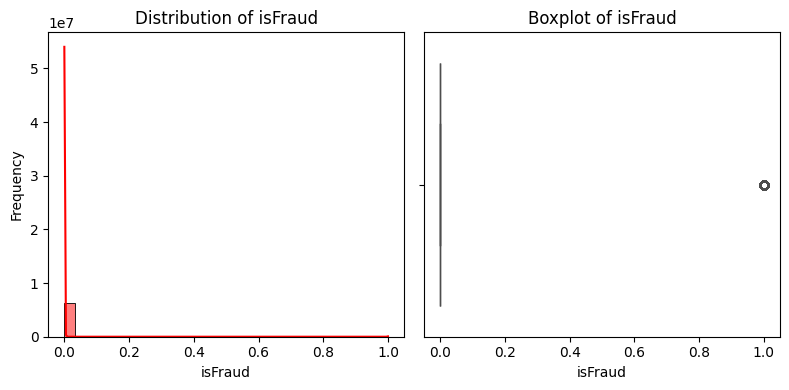


--- isFlaggedFraud ---

Mean: 0.00
Median: 0.00
Std Dev: 0.00
Min: 0.00
Max: 1.00


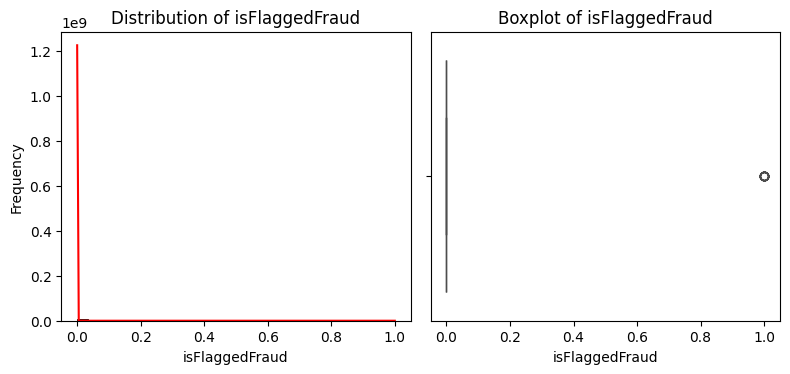

In [51]:
print("\n=== Numerical VARIABLES ===\n")

numerical_cols = []
for col in df.select_dtypes( include= ["number"] ).columns:
    numerical_cols.append(col)
print(numerical_cols)

for col in numerical_cols:
    print(f"\n--- { col } ---\n")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Std Dev: {df[col].std():.2f}")
    print(f"Min: {df[col].min():.2f}")
    print(f"Max: {df[col].max():.2f}")

    # Visualization
    plt.figure( figsize=(8,4) )

     # Histogram
    plt.subplot(1,2,1)
    sns.histplot(df[col], bins=30, kde=True, color = "red")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col], color = "blue")
    plt.title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

### BIVARIENT ANALYSIS

#### Catgoical vs Target columns


=== BIVARIATE ANALYSIS (CATEGORICAL vs TARGET) ===

['type']


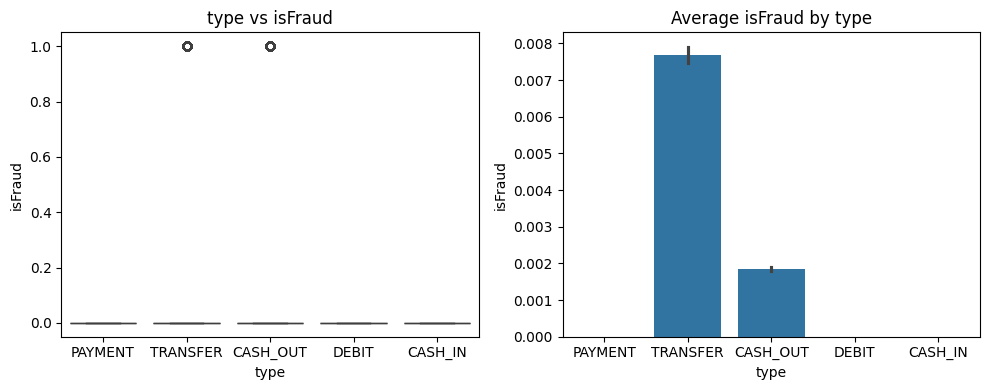

In [52]:
print("\n=== BIVARIATE ANALYSIS (CATEGORICAL vs TARGET) ===\n")

target = "isFraud"

categorical_cols = []
for col in df.select_dtypes(include='object').columns:
    if df[col].nunique() < 20:
        categorical_cols.append(col)
print(categorical_cols)

for col in categorical_cols:
    # Visualization
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.boxplot(x=df[col], y=df[target])
    plt.title(f"{col} vs {target}")

    plt.subplot(1,2,2)
    sns.barplot(x=df[col], y=df[target])
    plt.title(f"Average {target} by {col}")

    plt.tight_layout()
    plt.show()

### MULTIVARIENT ANALYSIS

In [53]:
# select numeric columns only
numeric_df = df.select_dtypes(include=['number'])
# correlation matrix
corr_matrix = numeric_df.corr()

# correlation with target
target_corr = corr_matrix["isFraud"].sort_values(ascending=False)

print(target_corr)

isFraud           1.000000
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64


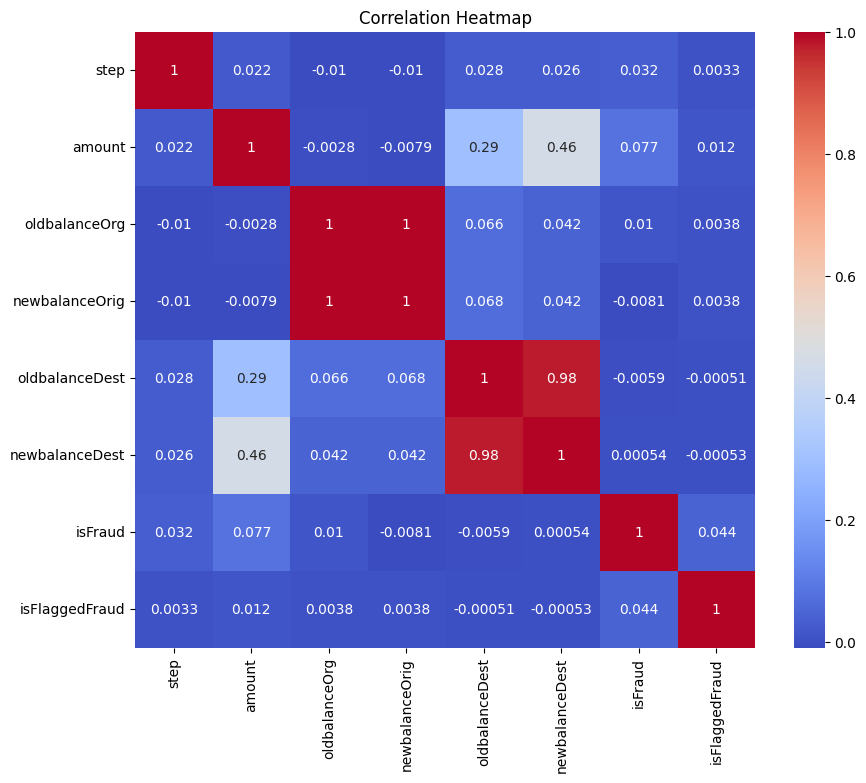

In [54]:
# select numeric columns only
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

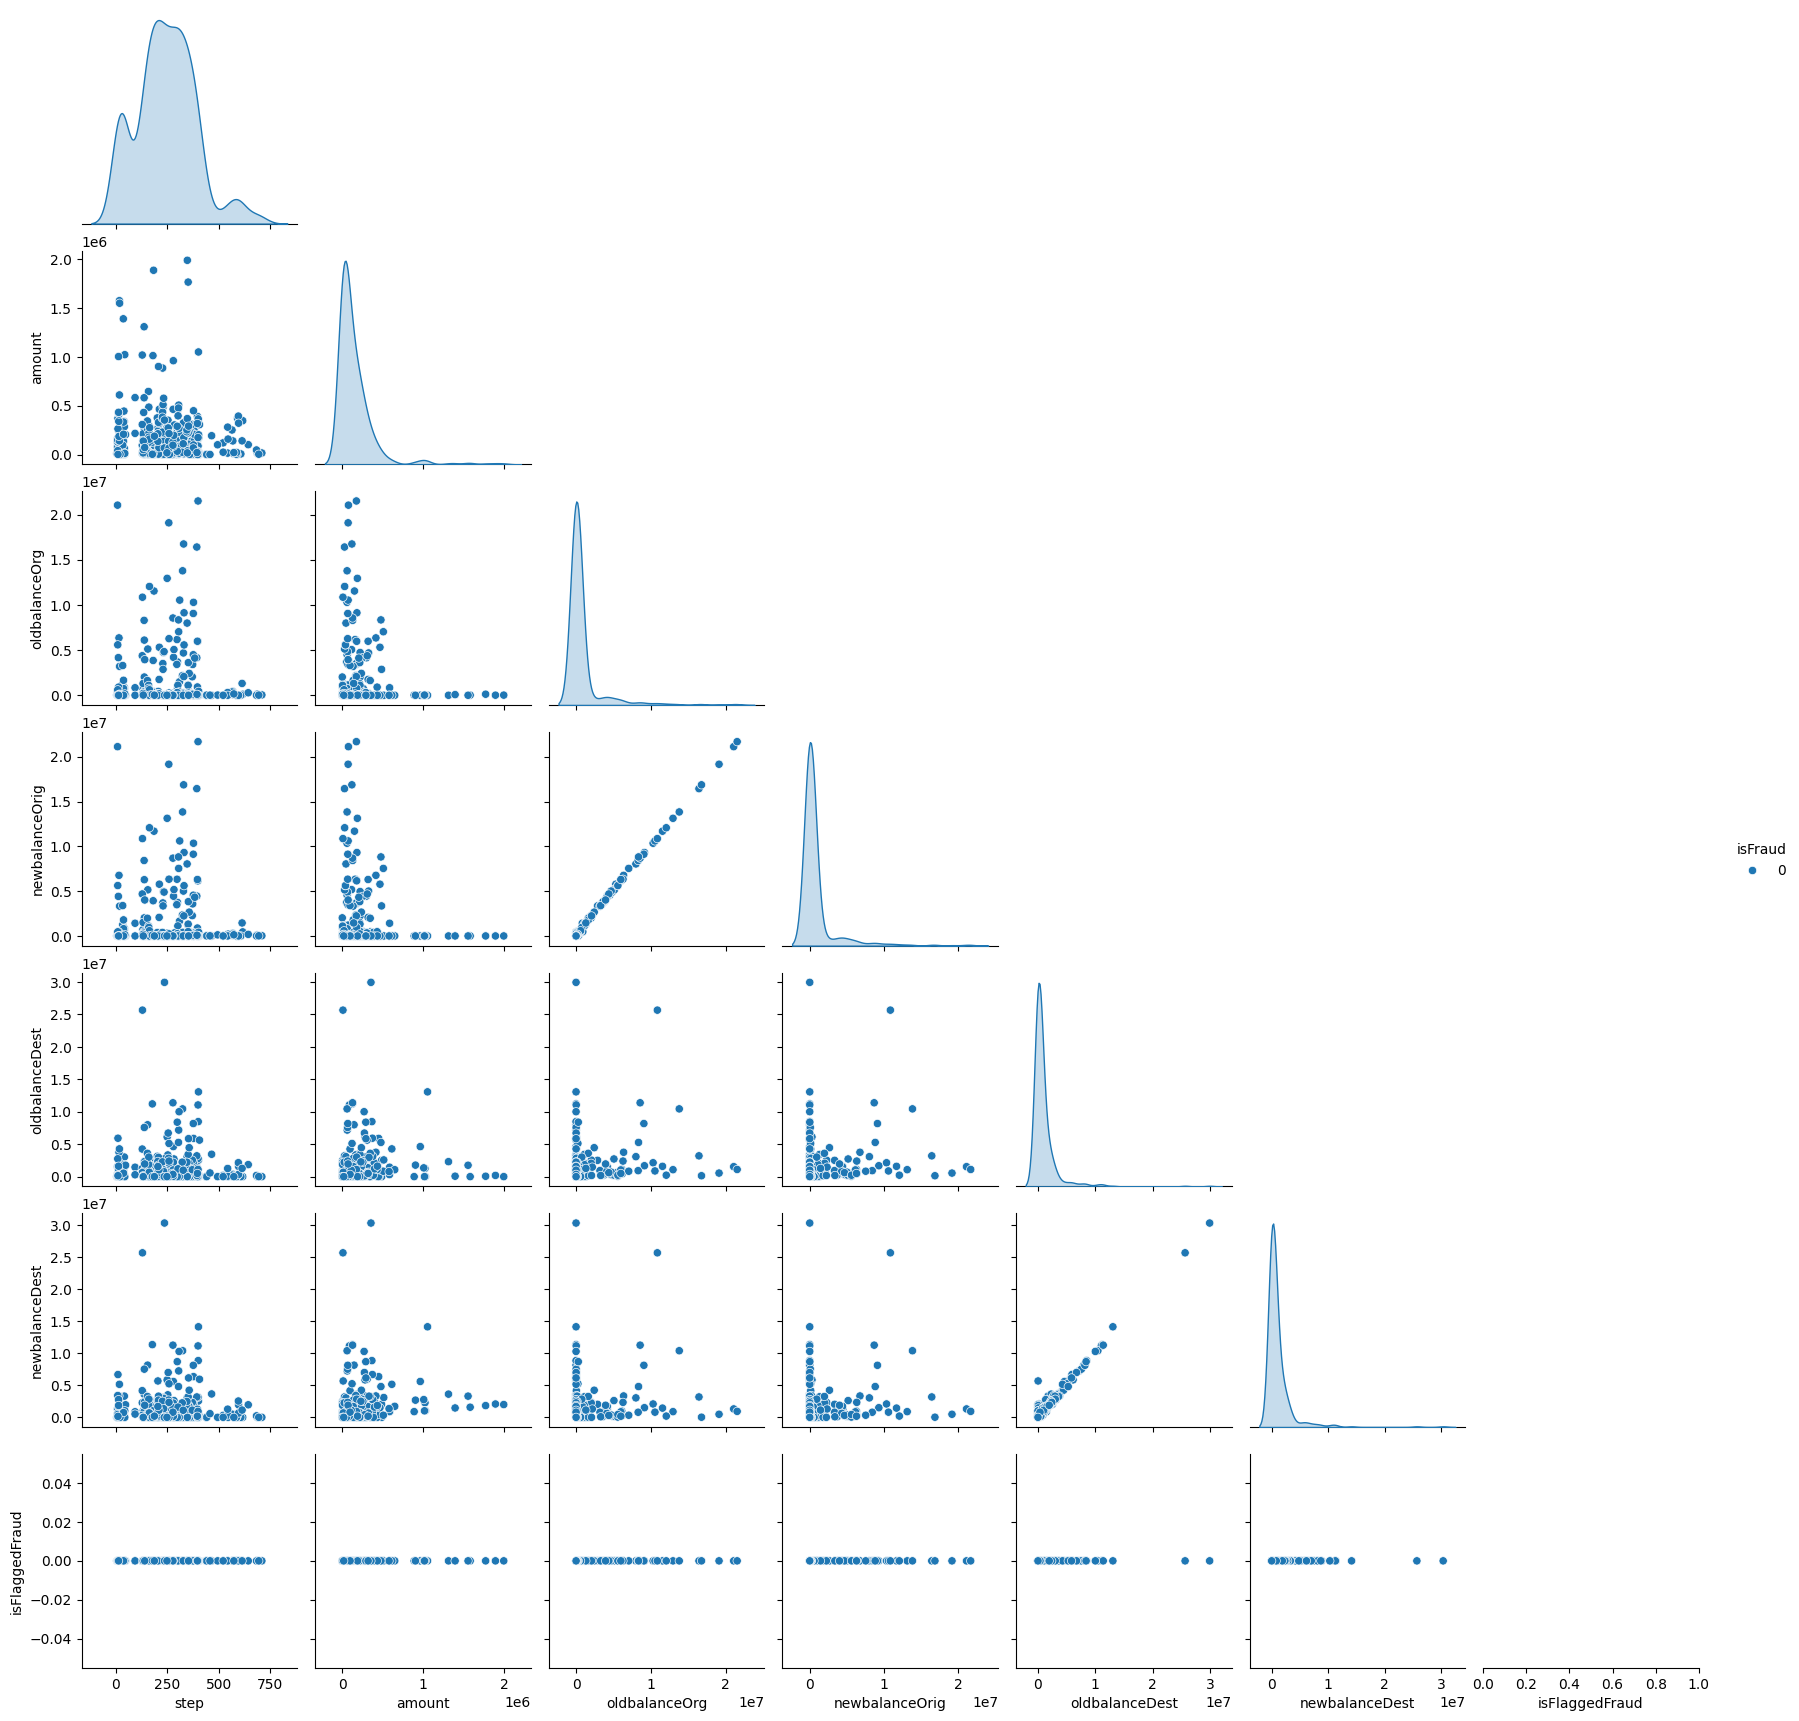

In [55]:
sns.pairplot(
    df.sample(500),
    hue="isFraud",
    diag_kind="kde",
    corner=True
)
plt.show()

# Data Preprocessing

### Feature Engineering

In [4]:
# ==========================================
# FEATURE ENGINEERING - PAYSIM DATASET
# ==========================================

import numpy as np
import pandas as pd

# ==========================================
# 1. BALANCE DIFFERENCE FEATURES
# ==========================================

# Sender balance difference
df['sender_balance_diff'] = (
    df['oldbalanceOrg'] - df['newbalanceOrig']
)

# Receiver balance difference
df['receiver_balance_diff'] = (
    df['newbalanceDest'] - df['oldbalanceDest']
)

# ==========================================
# 2. AMOUNT TO BALANCE RATIO
# ==========================================

df['amount_balance_ratio'] = (
    df['amount'] / (df['oldbalanceOrg'] + 1)
)

# ==========================================
# 3. LOG TRANSFORMATION
# ==========================================

df['amount_log'] = np.log1p(df['amount'])

# ==========================================
# 4. TIME FEATURES
# ==========================================

# Extract hour from step
df['hour'] = df['step'] % 24

# Extract day
df['day'] = df['step'] // 24

# Night transaction flag
df['is_night'] = (
    (df['hour'] >= 0) &
    (df['hour'] <= 6)
).astype(int)

# ==========================================
# 5. ZERO BALANCE FLAGS
# ==========================================

# Sender zero balance
df['is_sender_zero_balance'] = (
    df['oldbalanceOrg'] == 0
).astype(int)

# Receiver zero balance
df['is_receiver_zero_balance'] = (
    df['oldbalanceDest'] == 0
).astype(int)

# ==========================================
# 6. LARGE TRANSACTION FLAG
# ==========================================

df['is_large_transaction'] = (
    df['amount'] > 200000
).astype(int)


# ==========================================
# 7. DROP UNNECESSARY COLUMNS
# ==========================================

df.drop(
    ['nameOrig', 'nameDest', 'isFlaggedFraud'],
    axis=1,
    inplace=True
)

# ==========================================
# CHECK FINAL DATASET
# ==========================================

print("Feature Engineering Completed Successfully ✅")

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

Feature Engineering Completed Successfully ✅

Dataset Shape:
(6362620, 18)

Columns:
Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'sender_balance_diff',
       'receiver_balance_diff', 'amount_balance_ratio', 'amount_log', 'hour',
       'day', 'is_night', 'is_sender_zero_balance', 'is_receiver_zero_balance',
       'is_large_transaction'],
      dtype='object')


### Encoding

In [5]:
# Identify categorical columns in the dataset
categorical_columns = df.select_dtypes(include=['object']).columns
print(f"\n                  ----Categorical Columns----                  \n\n{categorical_columns}")
print()

for i in categorical_columns:
    unique = df[i].unique()
    a = len(unique)
    print(f"---- {i} ----\n")
    print(f"The column has a total of : {a} unique values")
    print(f"{unique}\n")


                  ----Categorical Columns----                  

Index(['type'], dtype='object')

---- type ----

The column has a total of : 5 unique values
['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']



In [6]:
# Applying Encoding

# One-hot encoding
df= pd.get_dummies( df, columns=['type'], drop_first=True ).astype(int)

In [7]:
df.dtypes

,0
step,int64
amount,int64
oldbalanceOrg,int64
newbalanceOrig,int64
oldbalanceDest,int64
newbalanceDest,int64
isFraud,int64
sender_balance_diff,int64
receiver_balance_diff,int64
amount_balance_ratio,int64


                     Feature  Importance
6        sender_balance_diff    0.725408
8       amount_balance_ratio    0.078221
3             newbalanceOrig    0.050947
10                      hour    0.032181
5             newbalanceDest    0.028365
19             type_TRANSFER    0.022547
18              type_PAYMENT    0.020293
1                     amount    0.016534
16             type_CASH_OUT    0.010849
14  is_receiver_zero_balance    0.005338
11                       day    0.003738
4             oldbalanceDest    0.002617
0                       step    0.001415
7      receiver_balance_diff    0.000616
9                 amount_log    0.000502
17                type_DEBIT    0.000232
2              oldbalanceOrg    0.000196
15      is_large_transaction    0.000000
12                  is_night    0.000000
13    is_sender_zero_balance    0.000000


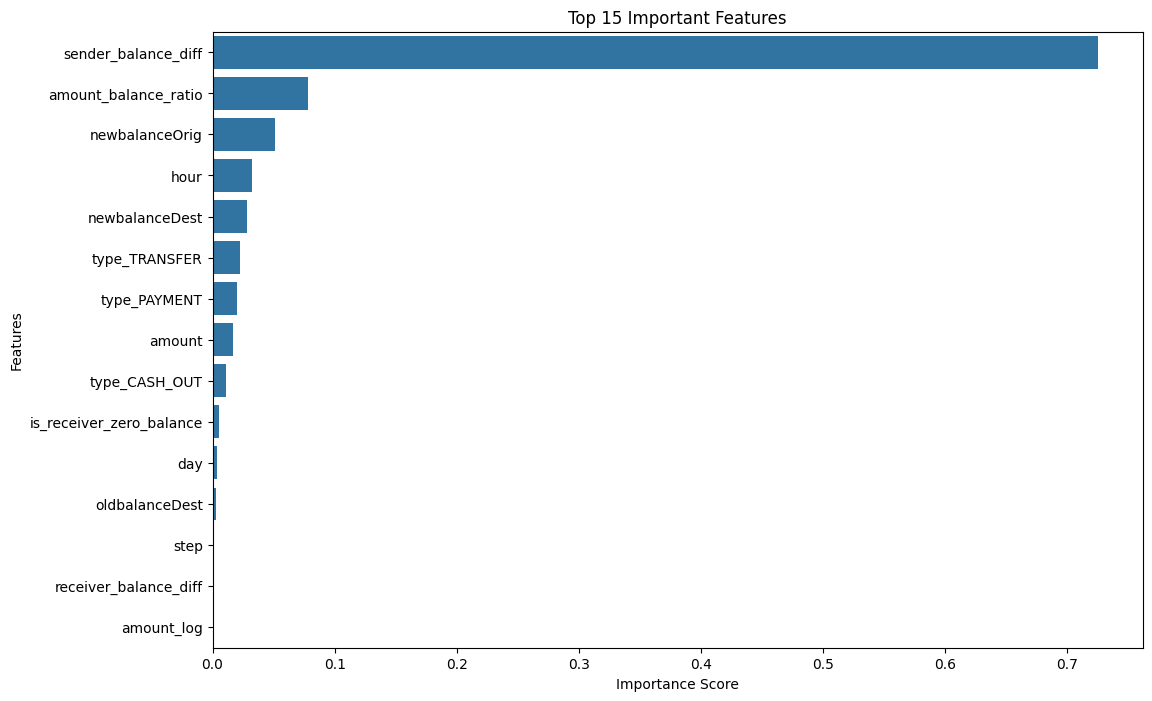


Selected Features:
6      sender_balance_diff
8     amount_balance_ratio
3           newbalanceOrig
10                    hour
5           newbalanceDest
19           type_TRANSFER
18            type_PAYMENT
1                   amount
16           type_CASH_OUT
Name: Feature, dtype: object

Final Selected Feature Shape:
(6362620, 9)


In [8]:
# ==========================================
# FEATURE SELECTION USING XGBOOST
# ==========================================

from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# DEFINE FEATURES & TARGET
# ==========================================

X = df.drop('isFraud', axis=1)

y = df['isFraud']

# ==========================================
# TRAIN XGBOOST MODEL
# ==========================================

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=773,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X, y)

# ==========================================
# GET FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# ==========================================
# DISPLAY FEATURE IMPORTANCE
# ==========================================

print(feature_importance)

# ==========================================
# VISUALIZE TOP FEATURES
# ==========================================

plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title("Top 15 Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

# ==========================================
# SELECT IMPORTANT FEATURES
# ==========================================

top_features = feature_importance[
    feature_importance['Importance'] > 0.01
]['Feature']

print("\nSelected Features:")
print(top_features)

# ==========================================
# CREATE FINAL FEATURE DATASET
# ==========================================

X_selected = X[top_features]

print("\nFinal Selected Feature Shape:")
print(X_selected.shape)

In [9]:
df.sample(5)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,sender_balance_diff,receiver_balance_diff,amount_balance_ratio,...,hour,day,is_night,is_sender_zero_balance,is_receiver_zero_balance,is_large_transaction,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
1348843,137,41185,0,0,0,0,0,0,0,41185,...,17,5,0,1,1,0,0,0,1,0
2684820,210,107355,149678,42322,229110,336465,0,107355,107355,0,...,18,8,0,0,0,0,1,0,0,0
3332703,253,589,0,0,0,0,0,0,0,589,...,13,10,0,1,1,0,0,0,1,0
5794960,401,27491,0,0,57990,85482,0,0,27491,27491,...,17,16,0,1,0,0,1,0,0,0
3505369,259,20763,119680,98916,0,0,0,20763,0,0,...,19,10,0,0,1,0,0,0,1,0


### Feature Scaling

In [10]:
# Identifying columns that may require feature scaling
numerical_features = df.select_dtypes(
    include=['int64','float64']).columns
numerical_features

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'sender_balance_diff',
       'receiver_balance_diff', 'amount_balance_ratio', 'amount_log', 'hour',
       'day', 'is_night', 'is_sender_zero_balance', 'is_receiver_zero_balance',
       'is_large_transaction', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT',
       'type_TRANSFER'],
      dtype='object')

In [11]:
for i in numerical_features:
    column_range = df[i].max() - df[i].min()
    print(f'Range of {i}: {column_range}')
print("")
print("-------------------------------------------------")
print("")
print("We will aplly Standard Scale after train test split and befor the models that required scalling")
print("\n-------------------------------------------------")

Range of step: 742
Range of amount: 92445516
Range of oldbalanceOrg: 59585040
Range of newbalanceOrig: 49585040
Range of oldbalanceDest: 356015889
Range of newbalanceDest: 356179278
Range of isFraud: 1
Range of sender_balance_diff: 11915267
Range of receiver_balance_diff: 118748664
Range of amount_balance_ratio: 92445516
Range of amount_log: 18
Range of hour: 23
Range of day: 30
Range of is_night: 1
Range of is_sender_zero_balance: 1
Range of is_receiver_zero_balance: 1
Range of is_large_transaction: 1
Range of type_CASH_OUT: 1
Range of type_DEBIT: 1
Range of type_PAYMENT: 1
Range of type_TRANSFER: 1

-------------------------------------------------

We will aplly Standard Scale after train test split and befor the models that required scalling

-------------------------------------------------


In [12]:
df.duplicated().sum()

np.int64(49671)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.isna().sum()

,0
step,0
amount,0
oldbalanceOrg,0
newbalanceOrig,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0
sender_balance_diff,0
receiver_balance_diff,0
amount_balance_ratio,0


### Train Test Split

In [16]:
#Splitting
from sklearn.model_selection import train_test_split
X = df.drop('isFraud', axis=1)
y = df['isFraud']
x_train , x_test , y_train , y_test = train_test_split( X , y , test_size=0.3 , random_state = 42 )# Model Training

# Models Training

In [17]:
# ===============================
# 🤖 MODEL SELECTION + TRAINING
# ===============================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Compute imbalance ratio for scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

imbalance_ratio = neg_count / pos_count

print(f'Imbalance ratio (neg/pos): {imbalance_ratio:.2f}')

# NOTE:
# KNN removed — too slow on large datasets
# XGBoost added — best for fraud detection

# ------------------------------
# 1. Select Models
# ------------------------------

models = {

    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=15,
        class_weight='balanced',
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        scale_pos_weight=imbalance_ratio,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        scale_pos_weight=imbalance_ratio,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
}

# ------------------------------
# 2. Train Models
# ------------------------------

trained_models = {}

for name, model in models.items():

    print(f"\n🚀 Training {name}...")

    model.fit(x_train, y_train)

    trained_models[name] = model

    print(f"✅ {name} trained successfully!")

# ------------------------------
# 3. Training Completed
# ------------------------------

print("\n🎯 All models trained successfully!")

Imbalance ratio (neg/pos): 761.96

🚀 Training Logistic Regression...
✅ Logistic Regression trained successfully!

🚀 Training Decision Tree...
✅ Decision Tree trained successfully!

🚀 Training Random Forest...
✅ Random Forest trained successfully!

🚀 Training LightGBM...
[LightGBM] [Info] Number of positive: 5792, number of negative: 4413272
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.654958 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2384
[LightGBM] [Info] Number of data points in the train set: 4419064, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001311 -> initscore=-6.635894
[LightGBM] [Info] Start training from score -6.635894
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

# Models Evalution

In [18]:
# ===============================
# 📊 MODEL EVALUATION
# ===============================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

results = {}

# ------------------------------
# Evaluate All Models
# ------------------------------

for name, model in trained_models.items():

    print(f"\n{'='*50}")
    print(f"📌 MODEL: {name}")
    print(f"{'='*50}")

    # --------------------------
    # Prediction
    # --------------------------

    y_pred = model.predict(x_test)

    # --------------------------
    # Calculate Metrics
    # --------------------------

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    # Store Results
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    # --------------------------
    # Confusion Matrix
    # --------------------------

    print("\n📌 Confusion Matrix:")

    print(confusion_matrix(y_test, y_pred))

    # --------------------------
    # Classification Report
    # --------------------------

    print("\n📌 Classification Report:")

    print(classification_report(y_test, y_pred))

# ------------------------------
# FINAL COMPARISON
# ------------------------------

print(f"\n{'='*50}")
print("🏆 FINAL MODEL COMPARISON")
print(f"{'='*50}")

for model_name, scores in results.items():

    print(f"\n🔹 {model_name}")

    for metric, value in scores.items():

        print(f"{metric}: {value:.4f}")


📌 MODEL: Logistic Regression

📌 Confusion Matrix:
[[1831752   59728]
 [    266    2139]]

📌 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98   1891480
           1       0.03      0.89      0.07      2405

    accuracy                           0.97   1893885
   macro avg       0.52      0.93      0.53   1893885
weighted avg       1.00      0.97      0.98   1893885


📌 MODEL: Decision Tree

📌 Confusion Matrix:
[[1891389      91]
 [     13    2392]]

📌 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1891480
           1       0.96      0.99      0.98      2405

    accuracy                           1.00   1893885
   macro avg       0.98      1.00      0.99   1893885
weighted avg       1.00      1.00      1.00   1893885


📌 MODEL: Random Forest

📌 Confusion Matrix:
[[1891478       2]
 [     13    2392]]

📌 Classification Report:
          

# Deployment

In [19]:
import joblib

# Save XGBoost model
joblib.dump(trained_models['Random Forest'], 'RandomForest_fraud_model.pkl')

# Save feature names
joblib.dump(x_train.columns.tolist(), 'feature_names.pkl')

print("✅ Model & feature names saved successfully!")

✅ Model & feature names saved successfully!


In [21]:
%%writefile app.py

# ==========================================
# 💳 FINTECH FRAUD DETECTION SYSTEM
# ==========================================

import streamlit as st
import pandas as pd
import numpy as np
import joblib

# ==========================================
# PAGE CONFIG
# ==========================================

st.set_page_config(
    page_title="Fraud Detection System",
    page_icon="💳",
    layout="wide"
)

# ==========================================
# LOAD MODEL & FEATURES
# ==========================================

@st.cache_resource
def load_artifacts():

    model = joblib.load("RandomForest_fraud_model.pkl")

    features = joblib.load("feature_names.pkl")

    return model, features

try:

    model, features = load_artifacts()

except Exception as e:

    st.error(f"❌ Error loading model files: {e}")

    st.stop()

# ==========================================
# PREPROCESSING FUNCTION
# ==========================================

def preprocess_input(raw):

    # --------------------------------------
    # Feature Engineering
    # --------------------------------------

    sender_balance_diff = (
        raw["oldbalanceOrg"] - raw["newbalanceOrig"]
    )

    receiver_balance_diff = (
        raw["newbalanceDest"] - raw["oldbalanceDest"]
    )

    amount_balance_ratio = (
        raw["amount"] / (raw["oldbalanceOrg"] + 1)
    )

    amount_log = np.log1p(raw["amount"])

    # --------------------------------------
    # Time Features
    # --------------------------------------

    hour = raw["step"] % 24

    day = raw["step"] // 24

    is_night = 1 if hour >= 22 or hour <= 6 else 0

    # --------------------------------------
    # Balance Features
    # --------------------------------------

    is_sender_zero_balance = (
        1 if raw["newbalanceOrig"] == 0 else 0
    )

    is_receiver_zero_balance = (
        1 if raw["newbalanceDest"] == 0 else 0
    )

    is_large_transaction = (
        1 if raw["amount"] > 200000 else 0
    )

    # --------------------------------------
    # Transaction Type Encoding
    # --------------------------------------

    transaction_types = {
        "type_CASH_OUT": 0,
        "type_DEBIT": 0,
        "type_PAYMENT": 0,
        "type_TRANSFER": 0
    }

    selected_type = f"type_{raw['type']}"

    if selected_type in transaction_types:
        transaction_types[selected_type] = 1

    # --------------------------------------
    # Final DataFrame
    # --------------------------------------

    row = {

        "step": raw["step"],

        "amount": raw["amount"],

        "oldbalanceOrg": raw["oldbalanceOrg"],

        "newbalanceOrig": raw["newbalanceOrig"],

        "oldbalanceDest": raw["oldbalanceDest"],

        "newbalanceDest": raw["newbalanceDest"],

        "sender_balance_diff": sender_balance_diff,

        "receiver_balance_diff": receiver_balance_diff,

        "amount_balance_ratio": amount_balance_ratio,

        "amount_log": amount_log,

        "hour": hour,

        "day": day,

        "is_night": is_night,

        "is_sender_zero_balance": is_sender_zero_balance,

        "is_receiver_zero_balance": is_receiver_zero_balance,

        "is_large_transaction": is_large_transaction,

        **transaction_types
    }

    return pd.DataFrame([row])[features]

# ==========================================
# UI
# ==========================================

st.title("💳 Fintech Fraud Detection System")

st.write(
    "Enter transaction details below to predict whether "
    "a transaction is fraudulent or legitimate."
)

st.divider()

# ==========================================
# INPUT SECTION
# ==========================================

col1, col2 = st.columns(2)

with col1:

    st.subheader("💰 Transaction Information")

    transaction_type = st.selectbox(
        "Transaction Type",
        ["CASH_OUT", "DEBIT", "PAYMENT", "TRANSFER"]
    )

    amount = st.number_input(
        "Transaction Amount",
        min_value=0.0,
        value=1000.0,
        step=100.0
    )

    step = st.number_input(
        "Transaction Step (Hour)",
        min_value=1,
        value=1,
        step=1
    )

with col2:

    st.subheader("🏦 Account Balances")

    oldbalanceOrg = st.number_input(
        "Sender Old Balance",
        min_value=0.0,
        value=5000.0
    )

    newbalanceOrig = st.number_input(
        "Sender New Balance",
        min_value=0.0,
        value=4000.0
    )

    oldbalanceDest = st.number_input(
        "Receiver Old Balance",
        min_value=0.0,
        value=1000.0
    )

    newbalanceDest = st.number_input(
        "Receiver New Balance",
        min_value=0.0,
        value=2000.0
    )

st.divider()

# ==========================================
# PREDICTION
# ==========================================

if st.button(
    "🔍 Predict Fraud",
    type="primary",
    use_container_width=True
):

    raw_data = {

        "step": step,

        "type": transaction_type,

        "amount": amount,

        "oldbalanceOrg": oldbalanceOrg,

        "newbalanceOrig": newbalanceOrig,

        "oldbalanceDest": oldbalanceDest,

        "newbalanceDest": newbalanceDest
    }

    # Preprocess Input
    X = preprocess_input(raw_data)

    # Prediction
    prediction = model.predict(X)[0]

    probability = model.predict_proba(X)[0][1]

    st.divider()

    # ======================================
    # RESULT DISPLAY
    # ======================================

    if prediction == 1:

        st.error(
            f"⚠️ Fraudulent Transaction Detected\n\n"
            f"Fraud Probability: {probability*100:.2f}%"
        )

    else:

        st.success(
            f"✅ Legitimate Transaction\n\n"
            f"Fraud Probability: {probability*100:.2f}%"
        )

    st.progress(
        float(probability),
        text=f"Fraud Risk Score: {probability*100:.2f}%"
    )

# ==========================================
# FOOTER
# ==========================================

st.divider()

st.caption(
    "📌 This ML system predicts potentially fraudulent "
    "financial transactions using a Random Forest model "
    "trained on the PaySim dataset."
)

Writing app.py
